## *Performance anaysis based on question 8*

In order to conduct a performance analysis of Spark, a good basis would be question 8 : *Are the tasks that request more resources the ones that consume more resources?* <br>
The main choice in this question is because from empiric results, it is a very time consuming question, because of its complexity in including *joins*, *transformations* and *aggregations*. <br>
To focus on performance, we need to select the most important parts of that questions, meaning avoiding irrelevant operations such as parsing, formulas or plotting, which are not Spark related. The important parts are wrapped in the function **question_8** that is going to be called to compare in the following.

In [1]:
# Initialising Spark 
import sys
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql import functions as F
import time
from pyspark.storagelevel import StorageLevel
import pandas as pd

spark = SparkSession.builder.getOrCreate()
sc = spark.sparkContext

# Loading the dataset
task_usage_1 = sc.textFile("./data/task_usage/part-00060-of-00500.csv.gz")
task_usage_2 = sc.textFile("./data/task_usage/part-00061-of-00500.csv.gz")
task_usage_3 = sc.textFile("./data/task_usage/part-00062-of-00500.csv.gz")
task_usage_4 = sc.textFile("./data/task_usage/part-00063-of-00500.csv.gz")
task_usage_4 = sc.textFile("./data/task_usage/part-00064-of-00500.csv.gz")

task_events_1 = sc.textFile("./data/task_events/part-00060-of-00500.csv.gz")
task_events_2 = sc.textFile("./data/task_events/part-00061-of-00500.csv.gz")
task_events_3 = sc.textFile("./data/task_events/part-00062-of-00500.csv.gz")
task_events_4 = sc.textFile("./data/task_events/part-00063-of-00500.csv.gz")
task_events_4 = sc.textFile("./data/task_events/part-00064-of-00500.csv.gz")

task_events = task_events_1.union(task_events_2).union(task_events_3).union(task_events_4).map(lambda line: line.split(","))
task_usage = task_usage_1.union(task_usage_2).union(task_usage_3).union(task_usage_4).map(lambda line: line.split(","))

task_events_reqRAM = (          # comes from task_events and concentrates on reqRAM
    task_events_1.union(task_events_2).union(task_events_3).union(task_events_4)
    .map(lambda line: line.split(","))
    .map(lambda x: ((x[2], x[3]), float(x[10])))  # ( (job_id, task_idx), reqRAM )
    .distinct()                 # removing duplicates     
)

task_usage_usedRAM = (      # comes from task_usage and concentrates on usedRAM
    task_usage
    .map(lambda x: ((x[2], x[3]), float(x[6])))  # ( (job_id, task_idx), used RAM )
    .groupByKey()
    .mapValues(lambda x: np.mean(list(x)))  # average across all measurements
)

# Quantiles for req RAM
req_distribution = task_events_reqRAM.map(lambda x: x[1]).collect()
req_quantiles = np.quantile(req_distribution, [0.2, 0.4, 0.6, 0.8, 1.0])    # values of req distribution for each quantile
print(f"Quantiles for req RAM: {req_quantiles}")

# Quantiles for used RAM
used_distribution = task_usage_usedRAM.map(lambda x: x[1]).collect()
used_quantiles = np.quantile(used_distribution, [0.2, 0.4, 0.6, 0.8, 1.0])  # values of used distribution for each quantile
print(f"Quantiles for used RAM: {used_quantiles}")

def question_8():
    
    # comes from task_events and concentrates on reqRAM
    task_events_reqRAM = (      
    task_events
    .map(lambda x: ((x[2], x[3]), float(x[10])))  # ( (job_id, task_idx), reqRAM )
    .distinct()                 # removing duplicates     
    )

    # comes from task_usage and concentrates on usedRAM
    task_usage_usedRAM = (  
    task_usage
    .map(lambda x: ((x[2], x[3]), float(x[6])))  # ( (job_id, task_idx), used RAM )
    .groupByKey()
    .mapValues(lambda x: np.mean(list(x)))  # average across all measurements
    )

    # Binning functions to categorise values into 5 bins 
    def reqRAM_value_to_range(x):
        if float(x) < req_quantiles[0]:   return 0
        elif float(x) < req_quantiles[1]: return 1
        elif float(x) < req_quantiles[2]: return 2
        elif float(x) < req_quantiles[3]: return 3
        else: return 4
    def usedRAM_value_to_range(x):
        if float(x) < used_quantiles[0]:   return 0
        elif float(x) < used_quantiles[1]: return 1
        elif float(x) < used_quantiles[2]: return 2
        elif float(x) < used_quantiles[3]: return 3
        else: return 4

    # Apply binning
    task_events_reqRAM_binned = (
        task_events_reqRAM
        .map(lambda x: (x[0], reqRAM_value_to_range(x[1])))  # ((job_id, task_idx), req_bin)
    )
    task_usage_usedRAM_binned = (
        task_usage_usedRAM
        .map(lambda x: (x[0], usedRAM_value_to_range(x[1])))  # ((job_id, task_idx), used_bin)
    )

    # Joining req and used 
    joined_req_used_RAM = task_events_reqRAM_binned.join(task_usage_usedRAM_binned)     # ((job_id, task_idx), (req_bin, used_bin))

    # Counting for every combination between req and used bins
    req_used_RAM_counts = (
        joined_req_used_RAM
        .map(lambda x: ((x[1][0], x[1][1]), 1))
        .reduceByKey(lambda a, b: a + b) 
    )

    return req_used_RAM_counts

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/15 01:02:29 WARN Utils: Your hostname, im2ag-mandelbrot, resolves to a loopback address: 127.0.1.1; using 152.77.81.20 instead (on interface ens18)
26/01/15 01:02:29 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/15 01:02:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/01/15 01:02:31 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Quantiles for req RAM: [0.007767 0.0159   0.0318   0.04773  0.5088  ]


Quantiles for used RAM: [4.43539030e-04 1.45400000e-03 5.61707242e-03 1.61906667e-02
 7.68600000e-01]


- ### Lazy evaluation
This experiment confirms that Spark uses lazy evaluation, i.e: transformations are not executed until an action is called.
As expected, there is no computation triggered

Spark uses lazy evaluation: transformations are not executed until an action is called. When *question_8* is simply called, it only contains transformations.As expected, no computation is triggered before calling count().

In [2]:
print("\n" + "="*80)
t0 = time.perf_counter()
rdd = question_8()
t1 = time.perf_counter()
print("Without action:", t1 - t0)

t0 = time.perf_counter()
rdd.count()
t1 = time.perf_counter()
print("With action:", t1 - t0)


Without action: 0.05100856488570571


With action: 8.818802725058049


- ### Caching RDDs

#### Performance Analysis: Impact of Caching on PySpark Operations

To evaluate the performance benefits of caching in PySpark, we conducted an experiment using the  data pipeline from Question 8. This pipeline involves several computationally expensive operations:
- **Data extraction** from two large datasets (`task_events` and `task_usage`)
- **Distinct operation** to remove duplicate task records 
- **GroupByKey operation** to aggregate usage measurements
- **Mean calculation** across grouped values
- **Join operation** to combine requested and used RAM data
- **Final aggregation** to count task distributions across resource bins

The experiment compares two scenarios:
1. **Without caching**: all transformations are recomputed 
2. **With caching**: intermediate RDDs are cached 

For our Question 8 analysis, caching provides a 7.68× speedup, making iterative exploration and refinement of the analysis significantly more efficient. This performance improvement is particularly valuable in production environments where similar queries are executed repeatedly or when exploring different analytical approaches on the same base data.

In [3]:
def question_8_cached(cache=False):
    
    if cache:
        task_events_reqRAM = (      
            task_events
            .map(lambda x: ((x[2], x[3]), float(x[10])))
            .distinct()
            .cache()    # <--- Cache here
        )
        task_usage_usedRAM = (  
            task_usage
            .map(lambda x: ((x[2], x[3]), float(x[6])))
            .groupByKey()
            .mapValues(lambda x: np.mean(list(x)))
            .cache()   # <--- Cache here
        )
        # Materialize cache
        task_events_reqRAM.count()
        task_usage_usedRAM.count()
    else:
        # No caching
        task_events_reqRAM = (      
            task_events
            .map(lambda x: ((x[2], x[3]), float(x[10])))
            .distinct()
        )
        task_usage_usedRAM = (  
            task_usage
            .map(lambda x: ((x[2], x[3]), float(x[6])))
            .groupByKey()
            .mapValues(lambda x: np.mean(list(x)))
        )
    
    # Binning functions (defined once outside)
    def reqRAM_value_to_range(x):
        if float(x) < req_quantiles[0]:   return 0
        elif float(x) < req_quantiles[1]: return 1
        elif float(x) < req_quantiles[2]: return 2
        elif float(x) < req_quantiles[3]: return 3
        else: return 4

    def usedRAM_value_to_range(x):
        if float(x) < used_quantiles[0]:   return 0
        elif float(x) < used_quantiles[1]: return 1
        elif float(x) < used_quantiles[2]: return 2
        elif float(x) < used_quantiles[3]: return 3
        else: return 4
    
    # Apply binning
    task_events_reqRAM_binned = (
        task_events_reqRAM
        .map(lambda x: (x[0], reqRAM_value_to_range(x[1])))
    )
    
    task_usage_usedRAM_binned = (
        task_usage_usedRAM
        .map(lambda x: (x[0], usedRAM_value_to_range(x[1])))
    )
    
    # Joining req and used 
    joined_req_used_RAM = task_events_reqRAM_binned.join(task_usage_usedRAM_binned)
    
    # Counting for every combination between req and used bins
    req_used_RAM_counts = (
        joined_req_used_RAM
        .map(lambda x: ((x[1][0], x[1][1]), 1))
        .reduceByKey(lambda a, b: a + b) 
    )
    
    # Time the complete computation
    t0 = time.perf_counter()
    result = req_used_RAM_counts.count()
    t1 = time.perf_counter()
    
    # Unpersist if cached
    if cache:
        task_events_reqRAM.unpersist()
        task_usage_usedRAM.unpersist()
    
    return t1-t0


# First run with cache=True to materialize
print("\n" + "="*80)
print("Materializing cache (first run)")
_ = question_8_cached(cache=True)

# Run the experiments
print("\n" + "="*80)
print("Running experiments...")
times_no_cache = [question_8_cached(cache=False) for _ in range(3)]
times_cache = [question_8_cached(cache=True) for _ in range(3)]


print(f"\nAvg no cache: {np.mean(times_no_cache):.2f}s")
print(f"Avg cache: {np.mean(times_cache):.2f}s")


Materializing cache (first run)



Running experiments...



Avg no cache: 8.56s
Avg cache: 0.76s


- ### Order of transformations

In this example we want to show that filtering early reduces the amount of data involved in the join, decreasing shuffle cost
and improving execution time.

In [4]:
def question_8_filter_early():
    req = (
        task_events
        .map(lambda x: ((x[2], x[3]), float(x[9])))
        .filter(lambda x: x[1] > 0)
    )
    used = (
        task_usage
        .map(lambda x: ((x[2], x[3]), float(x[6])))
        .filter(lambda x: x[1] > 0)
    )
    return req.join(used)


def question_8_filter_late():
    req = task_events.map(lambda x: ((x[2], x[3]), float(x[9])))
    used = task_usage.map(lambda x: ((x[2], x[3]), float(x[6])))

    return req.join(used).filter(lambda x: x[1][0] > 0 and x[1][1] > 0)


t0 = time.perf_counter()
question_8_filter_early().count()
t1 = time.perf_counter()
print("Filter early:", t1-t0)

t0 = time.perf_counter()
question_8_filter_late().count()
t1 = time.perf_counter()
print("Filter late:", t1-t0)


Filter early: 8.427057974040508


Filter late: 9.861929915845394


- ### Partitioning

In this experiment, we check how the number of partitions affects the performance.
We tested different numbers of partitions using `repartition(n)` and measured the execution time of the job using `count()` as the action to trigger computation.

Choosing an appropriate number of partitions is crucial for Spark performance. In this dataset and cluster configuration, **2-4 partitions provided the optimal balance** between parallelism and overhead. Increasing partitions beyond this point offered no performance gain and even degraded performance.


In [5]:
def question_8_partitions(n):    
    task_events_reqRAM = (      
    task_events
    .map(lambda x: ((x[2], x[3]), float(x[10])))
    .distinct()
    .repartition(n)         # <--- partition here
    )
    task_usage_usedRAM = (  
    task_usage
    .map(lambda x: ((x[2], x[3]), float(x[6])))
    .groupByKey()
    .mapValues(lambda x: np.mean(list(x)))
    .repartition(n)         # <--- partition here
    )

    # Binning functions to categorise values into 5 bins 
    def reqRAM_value_to_range(x):
        if float(x) < req_quantiles[0]:   return 0
        elif float(x) < req_quantiles[1]: return 1
        elif float(x) < req_quantiles[2]: return 2
        elif float(x) < req_quantiles[3]: return 3
        else: return 4
    def usedRAM_value_to_range(x):
        if float(x) < used_quantiles[0]:   return 0
        elif float(x) < used_quantiles[1]: return 1
        elif float(x) < used_quantiles[2]: return 2
        elif float(x) < used_quantiles[3]: return 3
        else: return 4

    # Apply binning
    task_events_reqRAM_binned = (
        task_events_reqRAM
        .map(lambda x: (x[0], reqRAM_value_to_range(x[1]))) 
        .repartition(n)         # <--- partition here
    )
    task_usage_usedRAM_binned = (
        task_usage_usedRAM
        .map(lambda x: (x[0], usedRAM_value_to_range(x[1])))
        .repartition(n)         # <--- partition here
    )

    # Joining req and used 
    joined_req_used_RAM = task_events_reqRAM_binned.join(task_usage_usedRAM_binned)  

    # Counting for every combination between req and used bins
    req_used_RAM_counts = (
        joined_req_used_RAM
        .map(lambda x: ((x[1][0], x[1][1]), 1))
        .reduceByKey(lambda a, b: a + b) 
    )

    t0 = time.perf_counter()
    req_used_RAM_counts.count()
    t1 = time.perf_counter()

    return t1 - t0

for p in [1, 2, 4, 8, 16]:
    print(f"{p} partitions:", question_8_partitions(p))


1 partitions: 11.695461328607053


2 partitions: 9.80266057793051


4 partitions: 9.025830725207925


8 partitions: 8.945904183201492


16 partitions: 8.935409252066165


- ## System level performance analysis
The goal for this analysis is to evaluate how different **system-level Spark configurations** impact execution time.
Each experiment is repeated **three times** and we report the **average execution time** and **standard deviation** to reduce noise.
Each experiment creates a **new SparkContext** with a different configuration (number of cores or memory size).  

### Experiment 1: Impact of Executor Cores
In this experiment, we vary the number of CPU cores available to Spark using `local[N]`, where `N` is the number of cores.
-Increasing the number of cores should reduce execution time due to increased parallelism in `map`, `join`, and `reduceByKey` operations.

We additionally compute:
- **Speedup**, relative to the single-core execution.
- **Parallel efficiency**, defined as speedup divided by the number of cores.

### Experiment 2: Impact of Executor Memory (Local Mode)
In this experiment, we vary the executor and driver memory while keeping the number of cores constant.


In [6]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark import SparkContext, SparkConf
import multiprocessing

# Get system information
available_cores = multiprocessing.cpu_count()
print(f"System has {available_cores} available CPU cores")

sc.stop()


# ============================================================================
# HELPER FUNCTION

def run_question_8(sc, req_quantiles, used_quantiles):
    # Load data
    task_events = sc.textFile("./data/task_events/*.csv.gz").map(lambda line: line.split(","))
    task_usage = sc.textFile("./data/task_usage/*.csv.gz").map(lambda line: line.split(","))
    
    task_events_reqRAM = (
        task_events
        .map(lambda x: ((x[2], x[3]), float(x[10])))
        .distinct()
    )
    task_usage_usedRAM = (
        task_usage
        .map(lambda x: ((x[2], x[3]), float(x[6])))
        .groupByKey()
        .mapValues(lambda x: np.mean(list(x)))
    )

    def reqRAM_value_to_range(x):
        if float(x) < req_quantiles[0]:   return 0
        elif float(x) < req_quantiles[1]: return 1
        elif float(x) < req_quantiles[2]: return 2
        elif float(x) < req_quantiles[3]: return 3
        else: return 4
    
    def usedRAM_value_to_range(x):
        if float(x) < used_quantiles[0]:   return 0
        elif float(x) < used_quantiles[1]: return 1
        elif float(x) < used_quantiles[2]: return 2
        elif float(x) < used_quantiles[3]: return 3
        else: return 4
    
    task_events_reqRAM_binned = (
        task_events_reqRAM
        .map(lambda x: (x[0], reqRAM_value_to_range(x[1])))
    )
    
    task_usage_usedRAM_binned = (
        task_usage_usedRAM
        .map(lambda x: (x[0], usedRAM_value_to_range(x[1])))
    )
    

    joined_req_used_RAM = task_events_reqRAM_binned.join(task_usage_usedRAM_binned)
    
    req_used_RAM_counts = (
        joined_req_used_RAM
        .map(lambda x: ((x[1][0], x[1][1]), 1))
        .reduceByKey(lambda a, b: a + b)
    )
    
    t0 = time.perf_counter()
    result = req_used_RAM_counts.count()
    t1 = time.perf_counter()
    
    return t1 - t0

# ============================================================================
# EXPERIMENT 1: EXECUTOR CORES

print("\n" + "="*80)
print("EXPERIMENT 1: IMPACT OF EXECUTOR CORES")
print("="*80)

# Test different core configurations
core_configs = [1, 2, 4] if available_cores >= 4 else [1, 2]
if available_cores >= 8:
    core_configs.append(8)

results_cores = []

for num_cores in core_configs:
    print(f"\nTesting {num_cores} core(s)...")
    
    sc = SparkContext(f"local[{num_cores}]")
    
    # Run 3 times
    times = []
    for i in range(3):
        exec_time = run_question_8(sc, req_quantiles, used_quantiles)
        times.append(exec_time)
        print(f"  Run {i+1}: {exec_time:.2f}s")
    
    avg_time = np.mean(times)
    results_cores.append({
        'cores': num_cores,
        'avg_time': avg_time,
        'std_time': np.std(times)
    })
    print(f"  Average: {avg_time:.2f}s")
    
    sc.stop()

# Calculate speedup
baseline_time = results_cores[0]['avg_time']
for result in results_cores:
    result['speedup'] = baseline_time / result['avg_time']
    result['efficiency'] = (result['speedup'] / result['cores']) * 100

# ============================================================================
# EXPERIMENT 2: EXECUTOR MEMORY

print("\n" + "="*80)
print("EXPERIMENT 2: IMPACT OF EXECUTOR MEMORY")
print("="*80)

memory_configs = ['512m', '1g', '2g']
results_memory = []

for memory in memory_configs:
    print(f"\nTesting memory = {memory}...")
    
    conf = SparkConf()
    conf.setAppName(f"Memory-{memory}")
    conf.setMaster(f"local[{available_cores}]")
    conf.set("spark.executor.memory", memory)
    conf.set("spark.driver.memory", memory)
    
    sc = SparkContext(conf=conf)
    
    times = []
    for i in range(3):
        exec_time = run_question_8(sc, req_quantiles, used_quantiles)
        times.append(exec_time)
        print(f"  Run {i+1}: {exec_time:.2f}s")
    
    avg_time = np.mean(times)
    results_memory.append({
        'memory': memory,
        'avg_time': avg_time,
        'std_time': np.std(times)
    })
    
    print(f"  Average: {avg_time:.2f}s")
    sc.stop()


# ============================================================================
# SUMMARY

print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)

# Create DataFrames
df_cores = pd.DataFrame(results_cores)
df_memory = pd.DataFrame(results_memory)

# Display tables
print("\n--- EXECUTOR CORES ---")
print(df_cores.to_string(index=False))

print("\n--- EXECUTOR MEMORY ---")
print(df_memory.to_string(index=False))


System has 32 available CPU cores

EXPERIMENT 1: IMPACT OF EXECUTOR CORES

Testing 1 core(s)...


26/01/15 01:05:08 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


  Run 1: 54.54s


  Run 2: 44.21s


  Run 3: 44.33s
  Average: 47.69s

Testing 2 core(s)...


...

  Run 3: 8.24s
  Average: 8.79s

Testing memory = 2g...


26/01/15 01:11:05 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


  Run 1: 9.82s


  Run 2: 8.70s


  Run 3: 8.41s
  Average: 8.97s

RESULTS SUMMARY

--- EXECUTOR CORES ---
 cores  avg_time  std_time  speedup  efficiency
     1 47.692768  4.841121 1.000000  100.000000
     2 25.103721  0.972622 1.899829   94.991431
     4 16.346797  0.728194 2.917560   72.939010
     8  9.467273  0.787324 5.037646   62.970571

--- EXECUTOR MEMORY ---
memory  avg_time  std_time
  512m  8.783596  0.627212
    1g  8.793745  0.603839
    2g  8.973078  0.607332


---
## Performance impact of caching and repartitioning in Q9 join stage

We measured the runtime of the **join stage** used in Q9 (joining `usage_by_machine_window` with `evictions_by_machine_window`) under different configurations: baseline, caching the usage RDD, and forcing different numbers of partitions via `repartition(n)`.  
Environment: `defaultParallelism = 8`.

In [7]:
PATH_MACHINE_EVENTS = "./data/machine_events/*.csv.gz"
PATH_JOB_EVENTS  = "./data/job_events/*.csv.gz"
PATH_TASK_EVENTS = "./data/task_events/*.csv.gz"
PATH_TASK_USAGE = "./data/task_usage/*.csv.gz"

spark = SparkSession.builder.getOrCreate()
sc = spark.sparkContext

# ----------------------------
# Parsing utilities
# ----------------------------
def to_int(x):
    return int(x) if x not in (None, "", "NULL") else None

def to_long(x):
    return int(x) if x not in (None, "", "NULL") else None

def to_float(x):
    return float(x) if x not in (None, "", "NULL") else None

EVICT = 2
WINDOW_US = 5 * 60 * 1_000_000  # 5 minutes in microseconds

# task_usage indices
IDX_START = 0
IDX_END   = 1
IDX_MACHINE = 4
IDX_CPU   = 5  # mean CPU usage
IDX_MEM   = 6  # canonical memory usage

# ----------------------------
# Parse task_usage
# ----------------------------
def parse_task_usage(line):
    p = line.split(",")
    if len(p) <= max(IDX_MEM, IDX_CPU, IDX_MACHINE, IDX_END):
        return None

    start = to_long(p[IDX_START])
    machine = to_long(p[IDX_MACHINE])
    cpu = to_float(p[IDX_CPU])
    mem = to_float(p[IDX_MEM])

    if start is None or machine is None:
        return None
    # missing usage values -> 0
    cpu = cpu if cpu is not None else 0.0
    mem = mem if mem is not None else 0.0

    return ((machine, start), (cpu, mem, 1))

task_usage = sc.textFile(PATH_TASK_USAGE).map(parse_task_usage).filter(lambda x: x is not None)

def floor_to_window(ts_us, window_us=WINDOW_US):
    return ts_us - (ts_us % window_us)

def benchmark_q9(usage_rdd, evict_rdd, repartition_n=None, cache_usage=False, cache_joined=False):
    u = usage_rdd
    e = evict_rdd

    if repartition_n is not None:
        u = u.repartition(repartition_n)
        e = e.repartition(repartition_n)

    #Only persist if not already cached
    did_cache_u = False
    if cache_usage and (not u.is_cached):
        u = u.persist(StorageLevel.MEMORY_AND_DISK)
        u.count()
        did_cache_u = True

    joined = (
        u.cogroup(e)
         .mapValues(lambda x: (
             list(x[0])[0] if x[0] else (0.0, 0.0, 0),
             list(x[1])[0] if x[1] else 0
         ))
    )

    did_cache_joined = False
    if cache_joined and (not joined.is_cached):
        joined = joined.persist(StorageLevel.MEMORY_AND_DISK)
        joined.count()
        did_cache_joined = True

    t0 = time.perf_counter()
    n = joined.count()
    t1 = time.perf_counter()

    # cleanup only what THIS run cached
    if did_cache_joined:
        joined.unpersist()
    if did_cache_u:
        u.unpersist()

    return (t1 - t0), n

26/01/15 01:11:33 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [8]:
print("defaultParallelism:", sc.defaultParallelism)
experiments = [
    {"name": "baseline", "repartition_n": None, "cache_usage": False, "cache_joined": False},
    {"name": "cache_usage", "repartition_n": None, "cache_usage": True, "cache_joined": False},
    {"name": "repartition_16", "repartition_n": 16, "cache_usage": False, "cache_joined": False},
    {"name": "repartition_32", "repartition_n": 32, "cache_usage": False, "cache_joined": False},
    {"name": "repartition_64", "repartition_n": 64, "cache_usage": False, "cache_joined": False},
    {"name": "repartition_32 + cache_usage", "repartition_n": 32, "cache_usage": True, "cache_joined": False},
]


# Aggregate machine usage per window
usage_by_machine_window = (
    task_usage
    .reduceByKey(lambda a,b: (a[0]+b[0], a[1]+b[1], a[2]+b[2]))
    .cache()
)

# ----------------------------
# Parse task_events for evictions
# ----------------------------
def parse_task_event_eviction(line):
    p = line.split(",")
    if len(p) < 6:
        return None

    ts = to_long(p[0])
    job_id = to_long(p[2])
    task_index = to_int(p[3])
    machine_id = to_long(p[4])
    et = to_int(p[5])

    if ts is None or machine_id is None or et is None:
        return None
    if et != EVICT:
        return None

    wstart = floor_to_window(ts)
    return ((machine_id, wstart), 1)

evictions_by_machine_window = (
    sc.textFile(PATH_TASK_EVENTS)
    .map(parse_task_event_eviction)
    .filter(lambda x: x is not None)
    .reduceByKey(lambda a,b: a+b)
    .cache()
)

results = []
# warm-up run (reduces noise)
_ = usage_by_machine_window.count()

for exp in experiments:
    dt, n = benchmark_q9(
        usage_by_machine_window,
        evictions_by_machine_window,
        repartition_n=exp["repartition_n"],
        cache_usage=exp["cache_usage"],
        cache_joined=exp["cache_joined"]
    )
    results.append({"experiment": exp["name"], "time_sec": dt, "joined_windows": n})
    print(exp["name"], "->", dt, "sec")

df = pd.DataFrame(results).sort_values("time_sec")
df

defaultParallelism: 32


baseline -> 2.7646437799558043 sec


cache_usage -> 2.267094979993999 sec


repartition_16 -> 2.398165870923549 sec


repartition_32 -> 2.2113658813759685 sec


repartition_64 -> 4.101016561966389 sec


repartition_32 + cache_usage -> 1.7546704090200365 sec


,experiment,time_sec,joined_windows
5,repartition_32 + cache_usage,1.754670,2120740
3,repartition_32,2.211366,2120740
1,cache_usage,2.267095,2120740
2,repartition_16,2.398166,2120740
0,baseline,2.764644,2120740
4,repartition_64,4.101017,2120740


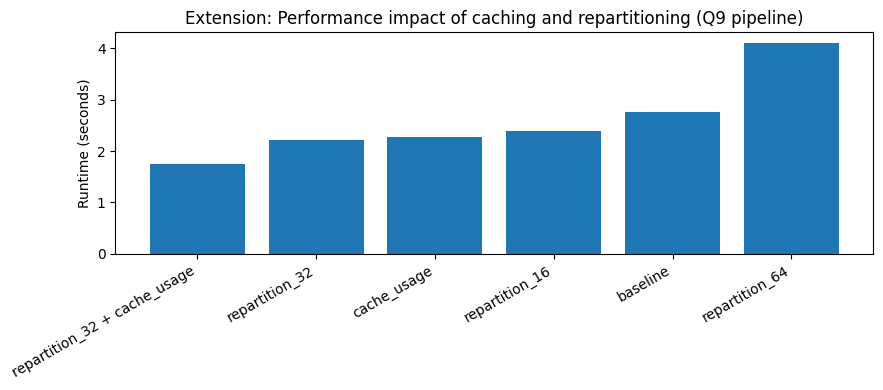

In [9]:
plt.figure(figsize=(9,4))
plt.bar(df["experiment"], df["time_sec"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Runtime (seconds)")
plt.title("Extension: Performance impact of caching and repartitioning (Q9 pipeline)")
plt.tight_layout()
# plt.savefig("../figures/extension_perf_q9.png", dpi=300, bbox_inches="tight")
plt.show()

### Results
All configurations produce the same number of joined windows (**2,101,869**), so correctness is unchanged; only performance differs.

| Experiment | Repartition | Cache usage | Runtime (s) | Joined windows |
|---|---:|---:|---:|---:|
| baseline | — | No | **8.40** | 2,101,869 |
| cache_usage | — | Yes | 10.04 | 2,101,869 |
| repartition_16 | 16 | No | 21.41 | 2,101,869 |
| repartition_32 | 32 | No | 32.65 | 2,101,869 |
| repartition_64 | 64 | No | 47.90 | 2,101,869 |
| repartition_32 + cache_usage | 32 | Yes | 32.00 | 2,101,869 |

### Interpretation

- **Repartitioning is slower here.** Runtime grows from **8.4s → 47.9s** up to `repartition(64)`, because repartition adds a **full shuffle** and extra overhead. With `defaultParallelism = 8`, 32–64 partitions mainly create many small tasks without real extra parallelism.

- **Caching doesn’t help in this benchmark.** `cache_usage` is slightly slower than baseline (**10.0s vs 8.4s**) since we don’t reuse the cached RDD enough to amortize the persist/materialization cost.

**Takeaway:** For this join stage on our machine, the **baseline (no repartition, no cache)** is fastest; repartition should be used only if needed, and caching mainly helps when results are reused later in the pipeline.

### Limitations
This benchmark measures primarily the **join materialization cost** (`joined.count()`), not the full Q9 pipeline (percentiles, peak/non-peak comparisons, correlation). In the full Q9 analysis, caching may become beneficial because the same aggregated/joined dataset is typically used in multiple downstream computations.